<a href="https://colab.research.google.com/github/cemilkaracam/Haar-Wavelet-Regularized-Approximation-of-Discontinuous-Functions/blob/main/Selective_Haar_Regularization_on_the_Discontinuous_Component.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

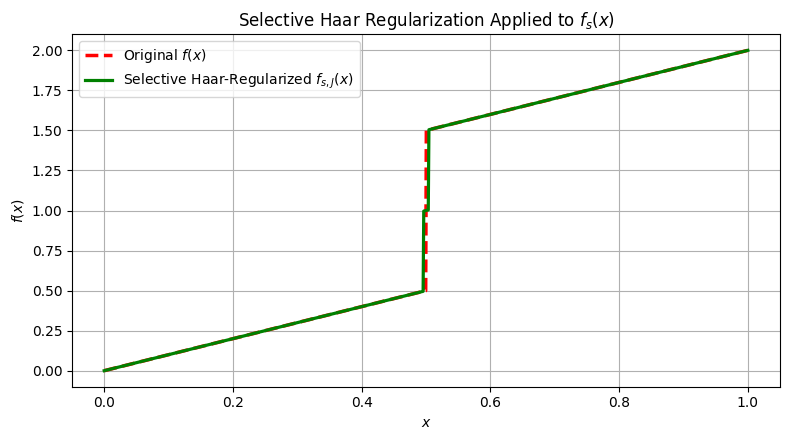

In [ ]:
# Selective Haar Regularization Applied to f_s(x)

# 1. Gerekli kütüphaneleri yükleyin (Colab için)
!pip install PyWavelets --quiet

# 2. Kütüphaneleri içe aktar
import numpy as np
import matplotlib.pyplot as plt
import pywt

# 3. Smooth ve kesikli bileşenleri tanımla
def f_c(x):
    return x

def f_s(x):
    return (x >= 0.5).astype(float)

# 4. Haar regularizasyon fonksiyonu
def haar_regularize(fx, level=3):
    coeffs = pywt.wavedec(fx, 'haar', level=level)
    coeffs_trunc = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]
    return pywt.waverec(coeffs_trunc, 'haar')[:len(fx)]

# 5. Domain ve fonksiyonları oluştur
x = np.linspace(0, 1, 1000)
f_orig = f_c(x) + f_s(x)
f_s_smoothed = haar_regularize(f_s(x), level=3)
f_decomp = f_c(x) + f_s_smoothed

# 6. Görselleştirme
plt.figure(figsize=(8, 4.5))
plt.plot(x, f_orig, 'r--', linewidth=2.5, label='Original $f(x)$')
plt.plot(x, f_decomp, 'g-', linewidth=2.3, label='Selective Haar-Regularized $f_{s,J}(x)$')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title('Selective Haar Regularization Applied to $f_s(x)$')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
